In [27]:
# ============================================================
# BASIC LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

# ============================================================
# TRAIN-TEST SPLIT
# ============================================================
from sklearn.model_selection import train_test_split

# ============================================================
# PREPROCESSING
# ============================================================
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    OneHotEncoder,
    OrdinalEncoder,
    PolynomialFeatures
)

from sklearn.impute import SimpleImputer

# ============================================================
# PIPELINE AND COLUMN TRANSFORMER
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# ============================================================
# IMBALANCED DATA HANDLING
# ============================================================
from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import (
    SMOTE,
    ADASYN,
    RandomOverSampler
)

from imblearn.under_sampling import RandomUnderSampler

# ============================================================
# MACHINE LEARNING MODELS
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# EVALUATION METRICS
# ============================================================
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve
)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [28]:
import pandas as pd

file_path = r"C:\Users\rishi\Downloads\HR_Job_Placement_Dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Shape: (51500, 26)
   age_years  gender  ssc_percentage  hsc_percentage  degree_percentage  \
0         27    Male       65.061656       83.842578          75.856526   
1         24    Male       67.885626       64.973305          73.093588   
2         33  Female       73.892471       68.834121          90.196460   
3         31    Male       74.145568       76.255126          75.586731   
4         28    Male       60.475937       65.786336          80.801010   

    degree_specialization  technical_score  aptitude_score  \
0        Computer Science        58.221909       89.566305   
1             Electronics        71.927978       54.591971   
2  Information Technology        72.445041       58.587088   
3              Mechanical        78.855676       61.022065   
4  Information Technology        68.286776       65.713731   

   communication_score  skills_match_percentage  ...  expected_ctc_lpa  \
0            64.474484                79.548913  ...  

In [29]:
df.shape

(51500, 26)

In [30]:
df.dtypes

age_years                      int64
gender                           str
ssc_percentage               float64
hsc_percentage               float64
degree_percentage            float64
degree_specialization            str
technical_score              float64
aptitude_score               float64
communication_score          float64
skills_match_percentage      float64
certifications_count           int64
internship_experience            str
years_of_experience            int64
career_switch_willingness        str
relevant_experience              str
previous_ctc_lpa             float64
expected_ctc_lpa             float64
company_tier                     str
job_role_match                   str
competition_level                str
bond_requirement                 str
notice_period_days           float64
layoff_history                   str
employment_gap_months        float64
relocation_willingness           str
status                           str
dtype: object

In [31]:
df.isnull().sum()

age_years                       0
gender                          0
ssc_percentage               2581
hsc_percentage               2065
degree_percentage               0
degree_specialization           0
technical_score                 0
aptitude_score                  0
communication_score             0
skills_match_percentage         0
certifications_count            0
internship_experience           0
years_of_experience             0
career_switch_willingness    8466
relevant_experience          8426
previous_ctc_lpa                0
expected_ctc_lpa                0
company_tier                    0
job_role_match               6131
competition_level               0
bond_requirement                0
notice_period_days           1582
layoff_history               8467
employment_gap_months        1097
relocation_willingness       8475
status                          0
dtype: int64

In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age_years,51500.0,27.505456,4.025385,21.0,24.000000,27.000000,31.000000,34.000000
ssc_percentage,48919.0,70.002505,7.976314,50.0,64.574733,69.971210,75.389057,95.000000
hsc_percentage,49435.0,72.060636,7.916654,50.0,66.720058,72.014383,77.389894,95.000000
degree_percentage,51500.0,74.010825,6.945579,55.0,69.305041,73.998187,78.707827,95.000000
technical_score,51500.0,68.027499,11.855145,40.0,59.935988,67.986042,76.049235,100.000000
aptitude_score,51500.0,64.005715,9.922397,40.0,57.204237,63.972079,70.727134,100.000000
communication_score,51500.0,66.106692,9.907488,45.0,59.252271,66.033268,72.840985,100.000000
skills_match_percentage,51500.0,73.937491,11.794258,45.0,65.851924,74.001772,82.112773,100.000000
certifications_count,51500.0,1.400136,1.184387,0.0,1.000000,1.000000,2.000000,8.000000
years_of_experience,51500.0,1.494117,1.375508,0.0,0.000000,1.000000,2.000000,5.000000


In [33]:
df['ssc_percentage']=df['ssc_percentage'].fillna(df['ssc_percentage'].median())
df['hsc_percentage']=df['hsc_percentage'].fillna(df['hsc_percentage'].median())

In [34]:
null =["career_switch_willingness","relevant_experience",'job_role_match',"layoff_history","relocation_willingness",'notice_period_days',
"employment_gap_months"]
null

['career_switch_willingness',
 'relevant_experience',
 'job_role_match',
 'layoff_history',
 'relocation_willingness',
 'notice_period_days',
 'employment_gap_months']

In [35]:
for col in null:
    print(df[col].value_counts())
    print('---'*40)
    print(df[col].isnull().sum())
    print('---'*40)

career_switch_willingness
Not Willing    28479
Willing        14555
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------
8466
------------------------------------------------------------------------------------------------------------------------
relevant_experience
Relevant        26305
Not Relevant    16769
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------
8426
------------------------------------------------------------------------------------------------------------------------
job_role_match
Matched        33456
Not Matched    11913
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------
6131
-----------------------------------------------------------------------------------------------------------------

In [36]:
fill_mode=["relevant_experience", 'relocation_willingness',"career_switch_willingness",'job_role_match','layoff_history']
for col in fill_mode:
    df[col]=df[col].fillna(df[col].mode()[0])

In [37]:
median_fill = ['notice_period_days','employment_gap_months']
for col in median_fill:
    df[col] = df[col].fillna(0.0)

In [38]:
df.isnull().sum()

age_years                    0
gender                       0
ssc_percentage               0
hsc_percentage               0
degree_percentage            0
degree_specialization        0
technical_score              0
aptitude_score               0
communication_score          0
skills_match_percentage      0
certifications_count         0
internship_experience        0
years_of_experience          0
career_switch_willingness    0
relevant_experience          0
previous_ctc_lpa             0
expected_ctc_lpa             0
company_tier                 0
job_role_match               0
competition_level            0
bond_requirement             0
notice_period_days           0
layoff_history               0
employment_gap_months        0
relocation_willingness       0
status                       0
dtype: int64

In [39]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51500 entries, 0 to 51499
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  51500 non-null  int64  
 1   gender                     51500 non-null  str    
 2   ssc_percentage             51500 non-null  float64
 3   hsc_percentage             51500 non-null  float64
 4   degree_percentage          51500 non-null  float64
 5   degree_specialization      51500 non-null  str    
 6   technical_score            51500 non-null  float64
 7   aptitude_score             51500 non-null  float64
 8   communication_score        51500 non-null  float64
 9   skills_match_percentage    51500 non-null  float64
 10  certifications_count       51500 non-null  int64  
 11  internship_experience      51500 non-null  str    
 12  years_of_experience        51500 non-null  int64  
 13  career_switch_willingness  51500 non-null  str    
 14  r

In [40]:
df.describe()

,age_years,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,years_of_experience,previous_ctc_lpa,expected_ctc_lpa,notice_period_days,employment_gap_months
count,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000
mean,27.505456,70.000936,72.058781,74.010825,68.027499,64.005715,66.106692,73.937491,1.400136,1.494117,4.844616,8.002649,19.478155,2.991087
std,4.025385,7.773871,7.756315,6.945579,11.855145,9.922397,9.907488,11.794258,1.184387,1.375508,2.125294,3.133792,24.712448,4.406479
min,21.000000,50.000000,50.000000,55.000000,40.000000,40.000000,45.000000,45.000000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000
25%,24.000000,64.899006,66.974815,69.305041,59.935988,57.204237,59.252271,65.851924,1.000000,0.000000,3.325635,5.672655,0.000000,0.000000
50%,27.000000,69.971210,72.014383,73.998187,67.986042,63.972079,66.033268,74.001772,1.000000,1.000000,4.807598,7.857337,15.000000,0.000000
75%,31.000000,75.066581,77.133064,78.707827,76.049235,70.727134,72.840985,82.112773,2.000000,2.000000,6.297570,10.093509,30.000000,6.000000
max,34.000000,95.000000,95.000000,95.000000,100.000000,100.000000,100.000000,100.000000,8.000000,5.000000,13.844566,26.524634,90.000000,18.000000


In [41]:
df['status'].value_counts()

status
Not Placed    35921
Placed        15579
Name: count, dtype: int64

In [42]:
35921/len(df)*100

69.7495145631068

In [43]:
15579/len(df)*100

30.250485436893204

In [44]:
df['years_of_experience'].describe()

count    51500.000000
mean         1.494117
std          1.375508
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          5.000000
Name: years_of_experience, dtype: float64

In [45]:
df['years_of_experience'].value_counts()

years_of_experience
0    15400
1    13892
2    10280
3     6749
4     3647
5     1532
Name: count, dtype: int64

In [46]:
def experience_category(years):
    if years == 0:
        return 'Fresher'
    elif 1 <= years <= 3:
        return 'Junior'
    elif 4 <= years <= 5:
        return 'Senior'
    else:
        return 'Senior'
df['experience_category'] = df['years_of_experience'].apply(experience_category)

df['experience_category'].value_counts()

experience_category
Junior     30921
Fresher    15400
Senior      5179
Name: count, dtype: int64

In [47]:
df[["ssc_percentage", "hsc_percentage", "degree_percentage"]].describe()

,ssc_percentage,hsc_percentage,degree_percentage
count,51500.000000,51500.000000,51500.000000
mean,70.000936,72.058781,74.010825
std,7.773871,7.756315,6.945579
min,50.000000,50.000000,55.000000
25%,64.899006,66.974815,69.305041
50%,69.971210,72.014383,73.998187
75%,75.066581,77.133064,78.707827
max,95.000000,95.000000,95.000000


In [48]:
df['academic_avg'] = (df['ssc_percentage'] + df['hsc_percentage'] + df['degree_percentage']) / 3

In [49]:

df['academic_avg']

0        74.920254
1        68.650839
2        77.641017
3        75.329142
4        69.021094
           ...    
51495    70.019669
51496    61.216887
51497    75.448042
51498    67.897270
51499    67.933867
Name: academic_avg, Length: 51500, dtype: float64

In [50]:
def academic_band(score):
    if score < 65:
        return 'Low'
    elif 65 <= score <= 75:
        return 'Medium'
    else:
        return 'High'

df['academic_performance_band'] = df['academic_avg'].apply(academic_band)

df['academic_performance_band'].value_counts()

academic_performance_band
Medium    36158
High      12659
Low        2683
Name: count, dtype: int64

In [51]:
df['skills_match_percentage'].describe()

count    51500.000000
mean        73.937491
std         11.794258
min         45.000000
25%         65.851924
50%         74.001772
75%         82.112773
max        100.000000
Name: skills_match_percentage, dtype: float64

In [52]:
def skills_match_level(score):
    if score < 65:
        return 'Low'
    elif 65 <= score <= 80:
        return 'Medium'
    else:
        return 'High'

df['skills_match_level'] = df['skills_match_percentage'].apply(skills_match_level)

df['skills_match_level'].value_counts()

skills_match_level
Medium    23869
High      15899
Low       11732
Name: count, dtype: int64

In [53]:
df[["technical_score","aptitude_score","communication_score"]]

,technical_score,aptitude_score,communication_score
0,58.221909,89.566305,64.474484
1,71.927978,54.591971,61.077306
2,72.445041,58.587088,79.494739
3,78.855676,61.022065,53.740386
4,68.286776,65.713731,61.438314
...,...,...,...
51495,55.923057,73.208032,69.108895
51496,69.525121,70.245612,54.959868
51497,73.073239,58.870416,71.219454
51498,48.270078,61.171900,71.650243


In [54]:
df[["technical_score","aptitude_score","communication_score"]].describe()

,technical_score,aptitude_score,communication_score
count,51500.000000,51500.000000,51500.000000
mean,68.027499,64.005715,66.106692
std,11.855145,9.922397,9.907488
min,40.000000,40.000000,45.000000
25%,59.935988,57.204237,59.252271
50%,67.986042,63.972079,66.033268
75%,76.049235,70.727134,72.840985
max,100.000000,100.000000,100.000000


In [55]:
df['interview_performance_category']=(df["technical_score"]+df["aptitude_score"]+df["communication_score"])/3

In [56]:
df['interview_performance_category'].describe()

count    51500.000000
mean        66.046635
std          6.116505
min         43.573924
25%         61.885635
50%         65.995618
75%         70.206600
max         93.011640
Name: interview_performance_category, dtype: float64

In [57]:
def interview_performance__level(score):
    if score < 65:
        return 'Low'
    elif 65 <= score <= 80:
        return 'Medium'
    else:
        return 'High'

df['interview_performance_level'] = df['interview_performance_category'].apply(skills_match_level)

df['interview_performance_level'].value_counts()

interview_performance_level
Medium    28509
Low       22417
High        574
Name: count, dtype: int64

#EDA Analysis

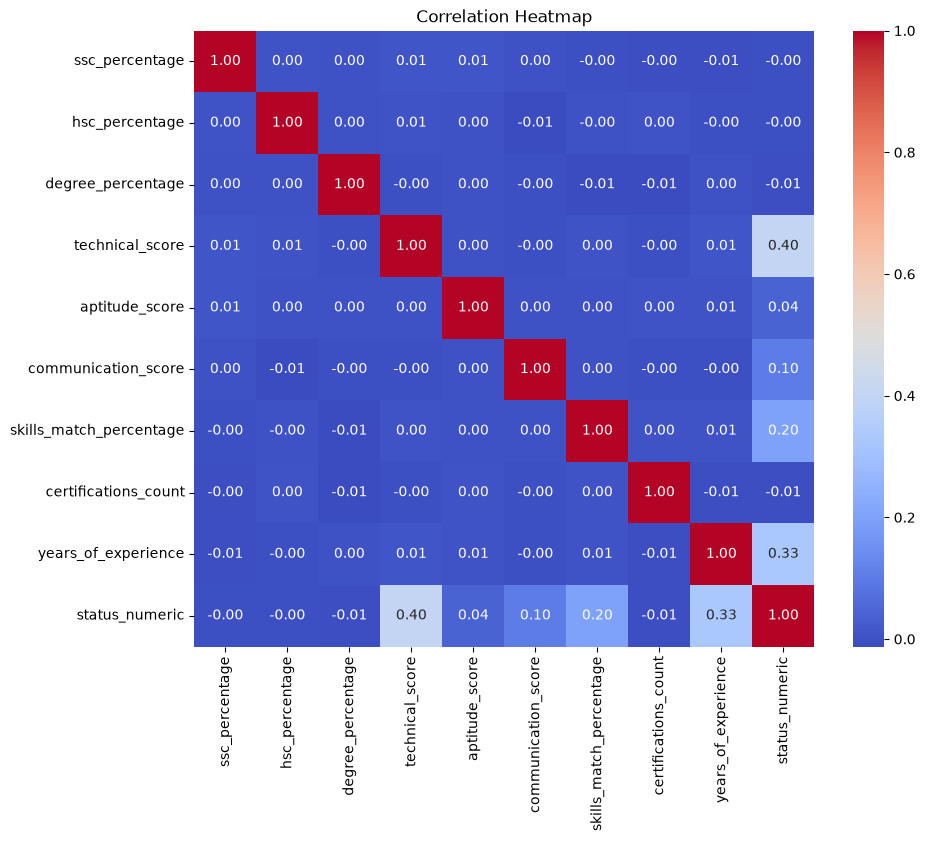

In [58]:
df['status_numeric'] = df['status'].map({'Placed': 1, 'Not Placed': 0})

numeric_cols = ['ssc_percentage', 'hsc_percentage', 'degree_percentage',
                 'technical_score', 'aptitude_score', 'communication_score',
                 'skills_match_percentage', 'certifications_count',
                 'years_of_experience', 'status_numeric']

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

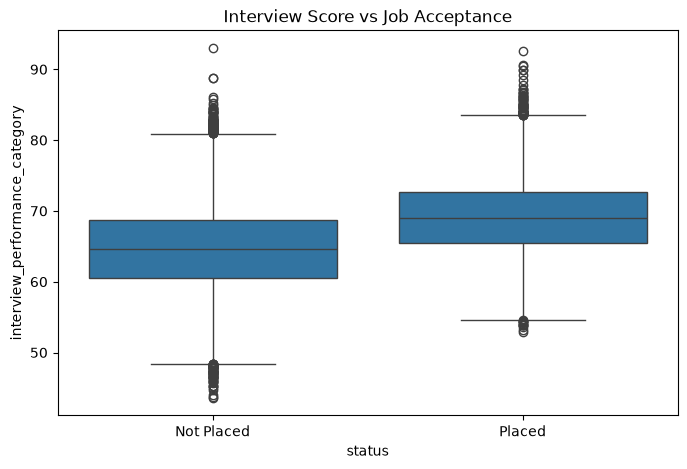

In [59]:
#Interview score vs acceptance
plt.figure(figsize=(8, 5))
sns.boxplot(x='status', y='interview_performance_category', data=df)
plt.title('Interview Score vs Job Acceptance')
plt.show()

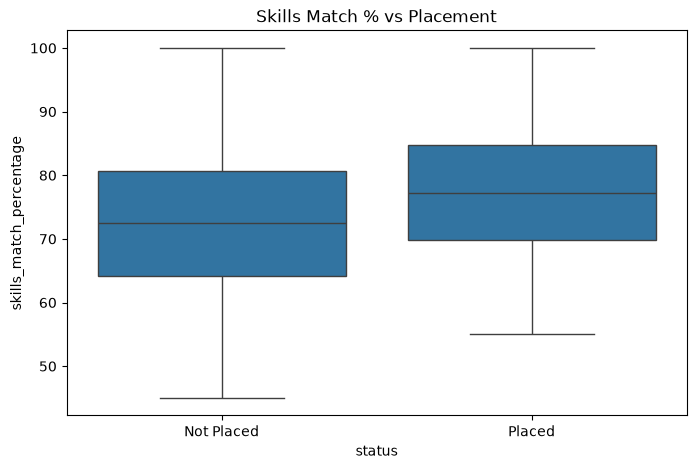

In [60]:
#Skills match % vs placement
plt.figure(figsize=(8, 5))
sns.boxplot(x='status', y='skills_match_percentage', data=df)
plt.title('Skills Match % vs Placement')
plt.show()

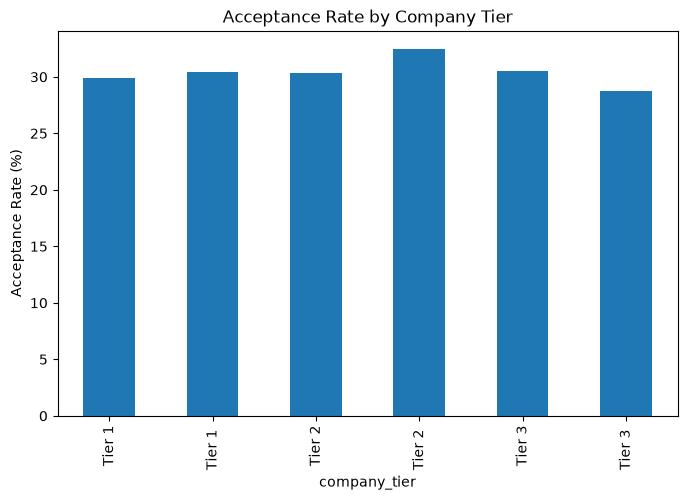

In [61]:
#Company tier vs acceptance rate
acceptance_by_tier = df.groupby('company_tier')['status_numeric'].mean() * 100
acceptance_by_tier.plot(kind='bar', figsize=(8,5))
plt.title('Acceptance Rate by Company Tier')
plt.ylabel('Acceptance Rate (%)')
plt.show()

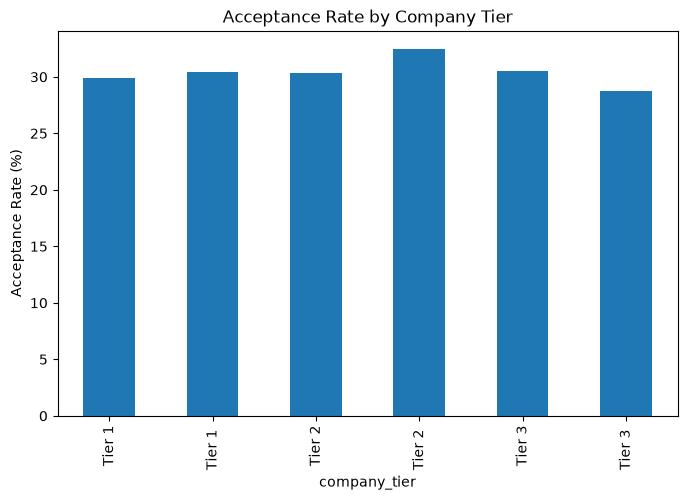

In [62]:
# Experience vs placement
acceptance_by_tier = df.groupby('company_tier')['status_numeric'].mean() * 100
acceptance_by_tier.plot(kind='bar', figsize=(8,5))
plt.title('Acceptance Rate by Company Tier')
plt.ylabel('Acceptance Rate (%)')
plt.show()

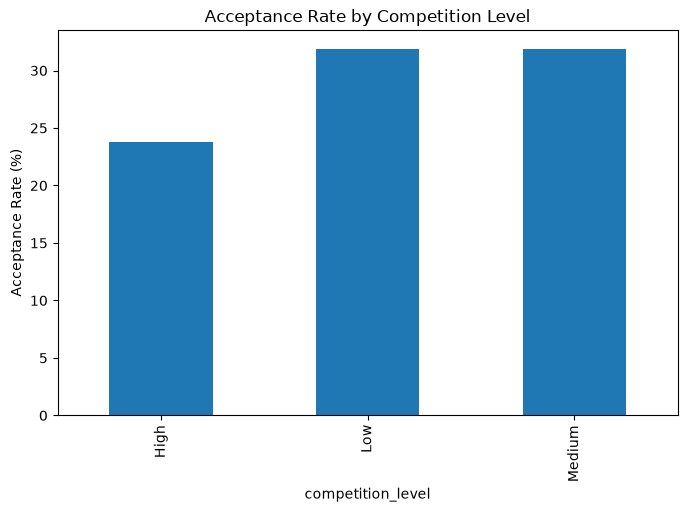

In [63]:
#Competition level vs acceptance
acceptance_by_comp = df.groupby('competition_level')['status_numeric'].mean() * 100
acceptance_by_comp.plot(kind='bar', figsize=(8,5))
plt.title('Acceptance Rate by Competition Level')
plt.ylabel('Acceptance Rate (%)')
plt.show()

In [64]:
df['interview_performance_category'].head()

0    70.754233
1    62.532418
2    70.175622
3    64.539376
4    65.146274
Name: interview_performance_category, dtype: float64

In [65]:
df[['status','skills_match_percentage']].value_counts()

status      skills_match_percentage
Not Placed  100.000000                 425
Placed      100.000000                 407
Not Placed  45.000000                  399
            79.548913                    2
            79.363751                    2
                                      ... 
            61.997596                    1
            77.767081                    1
            54.749371                    1
            92.333175                    1
            52.115751                    1
Name: count, Length: 48805, dtype: int64

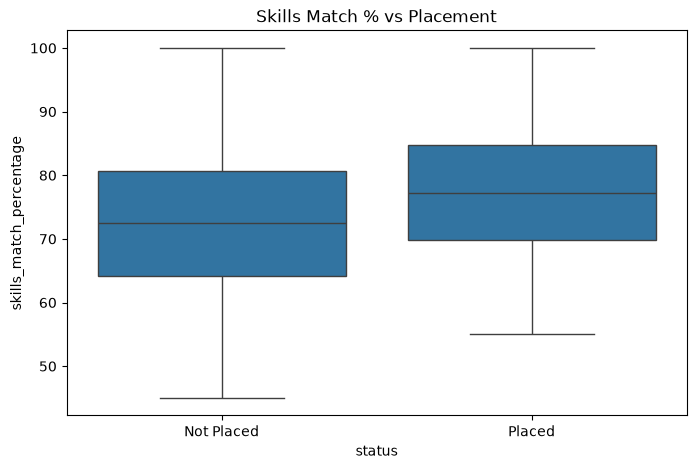

In [66]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='status', y='skills_match_percentage', data=df)
plt.title('Skills Match % vs Placement')
plt.show()

In [67]:
df['company_tier'].value_counts()

company_tier
Tier 1     19046
Tier 2     18301
Tier 3     12061
Tier 1       832
Tier 2       755
Tier 3       505
Name: count, dtype: int64

In [68]:
df['company_tier'].unique()

<StringArray>
['Tier 3', 'Tier 1', 'Tier 2', 'Tier 2 ', 'Tier 3 ', 'Tier 1 ']
Length: 6, dtype: str

In [69]:
df['company_tier'] = df['company_tier'].str.strip()

print(df['company_tier'].isnull().sum())

df['company_tier'] = df['company_tier'].fillna(df['company_tier'].mode()[0])

print(df['company_tier'].unique())

0
<StringArray>
['Tier 3', 'Tier 1', 'Tier 2']
Length: 3, dtype: str


company_tier
Tier 1    29.947681
Tier 2    30.452351
Tier 3    30.423365
Name: status_numeric, dtype: float64


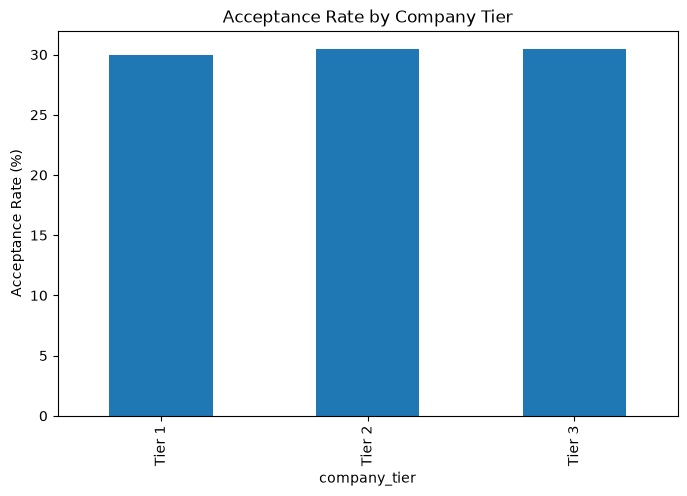

In [70]:
acceptance_by_tier = df.groupby('company_tier')['status_numeric'].mean() * 100
print(acceptance_by_tier)

acceptance_by_tier.plot(kind='bar', figsize=(8,5))
plt.title('Acceptance Rate by Company Tier')
plt.ylabel('Acceptance Rate (%)')
plt.show()

In [71]:
# Check for inconsistencies first
print(df['competition_level'].unique())

<StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str


In [72]:
df['competition_level'] = df['competition_level'].fillna(df['competition_level'].mode()[0])

# Verify
print(df['competition_level'].unique())

<StringArray>
['Medium', 'High', 'Low']
Length: 3, dtype: str


competition_level
High      23.790711
Low       31.867003
Medium    31.895677
Name: status_numeric, dtype: float64


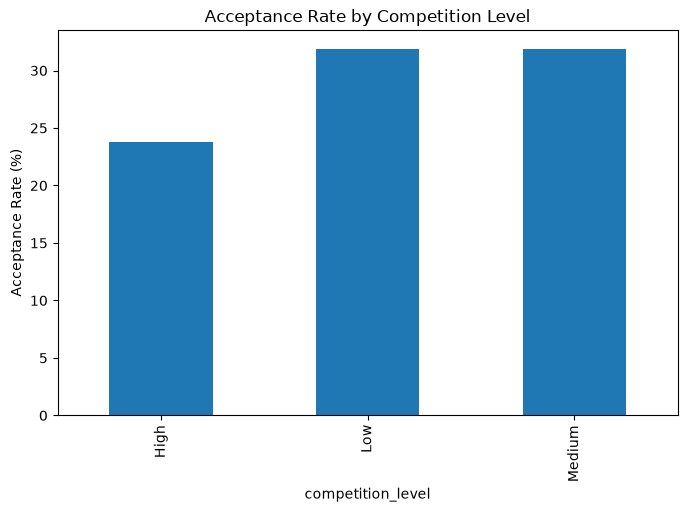

In [73]:
acceptance_by_comp = df.groupby('competition_level')['status_numeric'].mean() * 100
print(acceptance_by_comp)

acceptance_by_comp.plot(kind='bar', figsize=(8,5))
plt.title('Acceptance Rate by Competition Level')
plt.ylabel('Acceptance Rate (%)')
plt.show()

experience_category
Fresher    13.792208
Junior     33.511206
Senior     59.721954
Name: status_numeric, dtype: float64


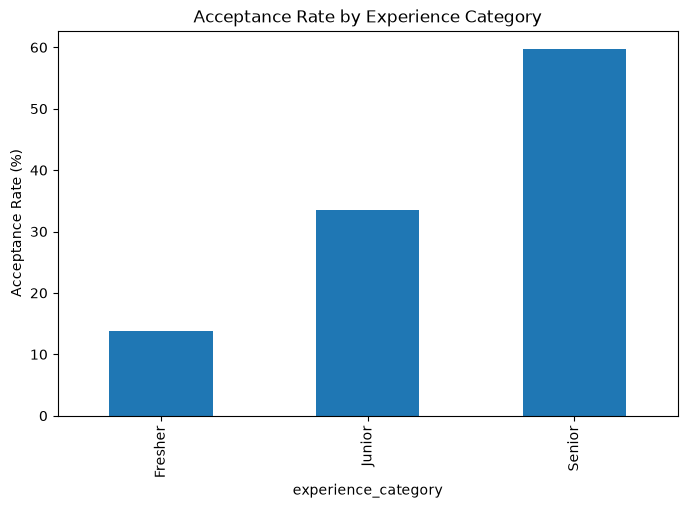

In [74]:
# Experience vs placement
acceptance_by_exp = df.groupby('experience_category')['status_numeric'].mean() * 100
print(acceptance_by_exp)

acceptance_by_exp.plot(kind='bar', figsize=(8,5))
plt.title('Acceptance Rate by Experience Category')
plt.ylabel('Acceptance Rate (%)')
plt.show()

In [75]:
df.select_dtypes(include='object').columns.tolist()

C:\Users\rishi\AppData\Local\Temp\ipykernel_30192\3152244773.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns.tolist()


['gender',
 'degree_specialization',
 'internship_experience',
 'career_switch_willingness',
 'relevant_experience',
 'company_tier',
 'job_role_match',
 'competition_level',
 'bond_requirement',
 'layoff_history',
 'relocation_willingness',
 'status',
 'experience_category',
 'academic_performance_band',
 'skills_match_level',
 'interview_performance_level']

In [76]:
for col in ['internship_experience', 'career_switch_willingness', 'relevant_experience',
            'bond_requirement', 'layoff_history', 'relocation_willingness']:
    print(col, df[col].unique())

internship_experience <StringArray>
['No', 'yes ', 'Yes', ' no']
Length: 4, dtype: str
career_switch_willingness <StringArray>
['Willing', 'Not Willing']
Length: 2, dtype: str
relevant_experience <StringArray>
['Relevant', 'Not Relevant']
Length: 2, dtype: str
bond_requirement <StringArray>
['Not Required', 'Required']
Length: 2, dtype: str
layoff_history <StringArray>
['No', 'Yes']
Length: 2, dtype: str
relocation_willingness <StringArray>
['Not Willing', 'Willing']
Length: 2, dtype: str


In [77]:
# Step 1: Clean text formatting
df['internship_experience'] = df['internship_experience'].str.strip().str.lower()

# Step 2: Encode all 6 binary columns
df['internship_experience'] = df['internship_experience'].map({'yes': 1, 'no': 0})
df['career_switch_willingness'] = df['career_switch_willingness'].map({'Willing': 1, 'Not Willing': 0})
df['relevant_experience'] = df['relevant_experience'].map({'Relevant': 1, 'Not Relevant': 0})
df['bond_requirement'] = df['bond_requirement'].map({'Required': 1, 'Not Required': 0})
df['layoff_history'] = df['layoff_history'].map({'Yes': 1, 'No': 0})
df['relocation_willingness'] = df['relocation_willingness'].map({'Willing': 1, 'Not Willing': 0})

# Step 3: Verify — should all be 0
print(df[['internship_experience', 'career_switch_willingness', 'relevant_experience',
    'bond_requirement', 'layoff_history', 'relocation_willingness']].isnull().sum())

internship_experience        0
career_switch_willingness    0
relevant_experience          0
bond_requirement             0
layoff_history               0
relocation_willingness       0
dtype: int64


In [78]:
# Ordinal mappings
company_tier_map = {'Tier 1': 1, 'Tier 2': 2, 'Tier 3': 3}
competition_map = {'Low': 1, 'Medium': 2, 'High': 3}
experience_cat_map = {'Fresher': 1, 'Junior': 2, 'Senior': 3}
level_map = {'Low': 1, 'Medium': 2, 'High': 3}

df['company_tier'] = df['company_tier'].map(company_tier_map)
df['competition_level'] = df['competition_level'].map(competition_map)
df['experience_category'] = df['experience_category'].map(experience_cat_map)
df['academic_performance_band'] = df['academic_performance_band'].map(level_map)
df['skills_match_level'] = df['skills_match_level'].map(level_map)
df['interview_performance_level'] = df['interview_performance_level'].map(level_map)

# Verify
cols_to_check = ['company_tier', 'competition_level', 'experience_category',
                  'academic_performance_band', 'skills_match_level', 'interview_performance_level']
print(df[cols_to_check].isnull().sum())

company_tier                   0
competition_level              0
experience_category            0
academic_performance_band      0
skills_match_level             0
interview_performance_level    0
dtype: int64


In [79]:
for col in ['gender', 'degree_specialization', 'job_role_match']:
    print(col, df[col].unique())

gender <StringArray>
['Male', 'Female', 'female', 'male']
Length: 4, dtype: str
degree_specialization <StringArray>
[      'Computer Science',            'Electronics', 'Information Technology',
             'Mechanical',                 'Others']
Length: 5, dtype: str
job_role_match <StringArray>
['Not Matched', 'Matched']
Length: 2, dtype: str


In [80]:
df['gender'] = df['gender'].str.strip().str.title()
print(df['gender'].unique())

<StringArray>
['Male', 'Female']
Length: 2, dtype: str


In [81]:
df['job_role_match'] = df['job_role_match'].map({'Matched': 1, 'Not Matched': 0})


In [82]:
df = pd.get_dummies(df, columns=['gender', 'degree_specialization'], drop_first=True)

print(df.isnull().sum().sum())
print(df.shape)

0
(51500, 36)


In [83]:
df = df.drop(columns=['status'])

X = df.drop(columns=['status_numeric'])
y = df['status_numeric']

print(X.shape, y.shape)

(51500, 34) (51500,)


In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)

(41200, 34) (10300, 34)


In [85]:

numeric_cols = ['age_years', 'ssc_percentage', 'hsc_percentage', 'degree_percentage',
                 'technical_score', 'aptitude_score', 'communication_score',
                 'skills_match_percentage', 'certifications_count', 'years_of_experience',
                 'previous_ctc_lpa', 'expected_ctc_lpa', 'notice_period_days',
                 'employment_gap_months', 'academic_avg']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(X_train_scaled[numeric_cols].describe())

          age_years  ssc_percentage  hsc_percentage  degree_percentage  \
count  4.120000e+04    4.120000e+04    4.120000e+04       4.120000e+04   
mean   4.527123e-17    5.918890e-16   -1.372106e-15       8.981812e-16   
std    1.000012e+00    1.000012e+00    1.000012e+00       1.000012e+00   
min   -1.609368e+00   -2.574352e+00   -2.838771e+00      -2.733155e+00   
25%   -8.649007e-01   -6.578065e-01   -6.575218e-01      -6.791346e-01   
50%   -1.204338e-01   -1.825913e-03   -3.258007e-03       1.321374e-03   
75%    8.721888e-01    6.499510e-01    6.539557e-01       6.774346e-01   
max    1.616656e+00    3.222176e+00    2.957353e+00       3.014748e+00   

       technical_score  aptitude_score  communication_score  \
count     4.120000e+04    4.120000e+04         4.120000e+04   
mean     -2.105759e-16   -2.262699e-16        -1.281046e-15   
std       1.000012e+00    1.000012e+00         1.000012e+00   
min      -2.362552e+00   -2.417107e+00        -2.125316e+00   
25%      -6.824607

In [86]:
# Logistic Regression
log_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)
y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.85      0.89      7184
           1       0.71      0.87      0.78      3116

    accuracy                           0.85     10300
   macro avg       0.82      0.86      0.84     10300
weighted avg       0.87      0.85      0.86     10300

ROC-AUC: 0.9377763415205949
[[6081 1103]
 [ 406 2710]]


In [87]:
#Decision Tree
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=10)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)
y_pred_proba_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_dt))
print(confusion_matrix(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.94      0.80      0.86      7184
           1       0.65      0.88      0.75      3116

    accuracy                           0.82     10300
   macro avg       0.80      0.84      0.81     10300
weighted avg       0.85      0.82      0.83     10300

ROC-AUC: 0.912792226914181
[[5735 1449]
 [ 372 2744]]


In [88]:
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, max_depth=12)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.85      0.90      7184
           1       0.73      0.91      0.81      3116

    accuracy                           0.87     10300
   macro avg       0.84      0.88      0.85     10300
weighted avg       0.89      0.87      0.87     10300

ROC-AUC: 0.9543473176020882
[[6120 1064]
 [ 280 2836]]


                           feature  importance
4                  technical_score    0.263924
10             years_of_experience    0.115486
27  interview_performance_category    0.090375
7          skills_match_percentage    0.074264
23             experience_category    0.060553
28     interview_performance_level    0.050858
16                  job_role_match    0.049887
14                expected_ctc_lpa    0.049870
9            internship_experience    0.028446
13                previous_ctc_lpa    0.025992
26              skills_match_level    0.024652
5                   aptitude_score    0.021435
6              communication_score    0.019865
20                  layoff_history    0.015238
12             relevant_experience    0.013129


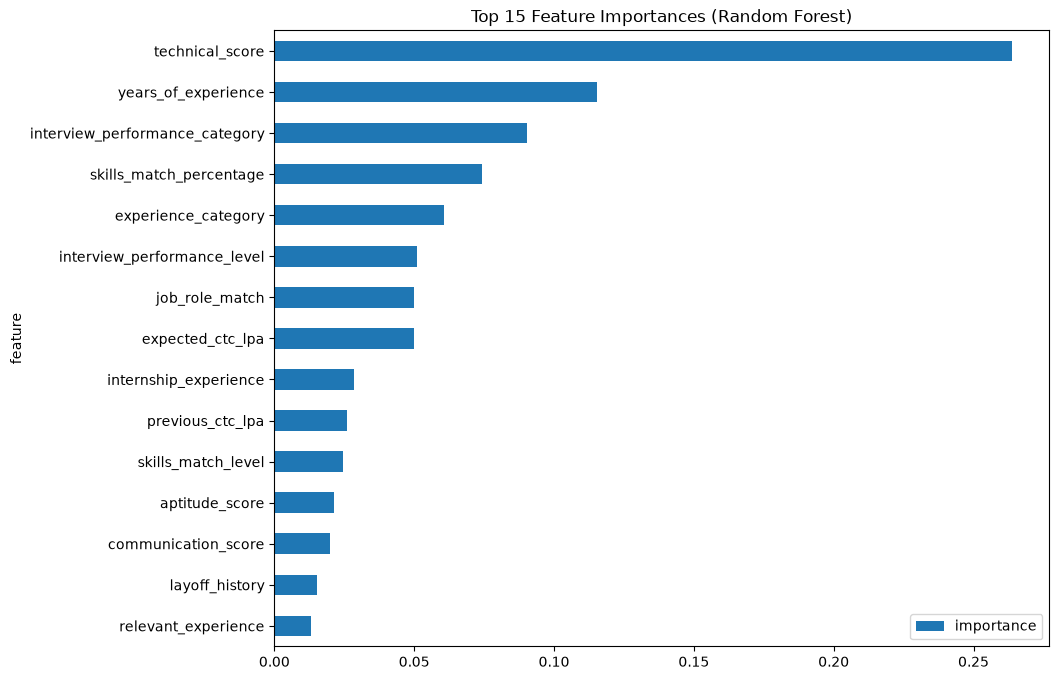

In [89]:

feature_importance = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(15))

feature_importance.head(15).plot(kind='barh', x='feature', y='importance', figsize=(10,8))
plt.title('Top 15 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

In [90]:
feature_importance = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(15))

                           feature  importance
4                  technical_score    0.263924
10             years_of_experience    0.115486
27  interview_performance_category    0.090375
7          skills_match_percentage    0.074264
23             experience_category    0.060553
28     interview_performance_level    0.050858
16                  job_role_match    0.049887
14                expected_ctc_lpa    0.049870
9            internship_experience    0.028446
13                previous_ctc_lpa    0.025992
26              skills_match_level    0.024652
5                   aptitude_score    0.021435
6              communication_score    0.019865
20                  layoff_history    0.015238
12             relevant_experience    0.013129


In [91]:
!pip install streamlit pyngrok -q

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\rishi\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [92]:
from pyngrok import ngrok
ngrok.set_auth_token("3GcAvOErmCt6MxbolZd1NUgsL3i_6aRo9ffTEThVnj5SMjwc5")

In [93]:
%%writefile job_acceptance_dashboard.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title="Job Acceptance Prediction Dashboard", layout="wide")
st.title("🎯 Job Acceptance Prediction System")
st.markdown("HR Analytics Dashboard — Candidate Placement & Acceptance Insights")

@st.cache_data
def load_data():
    df = pd.read_csv("cleaned_job_data.csv")
    return df

df = load_data()

# ---------------- Sidebar Filters ----------------
st.sidebar.header("Filters")

if "company_tier" in df.columns:
    tier_options = sorted(df["company_tier"].dropna().unique().tolist())
    selected_tier = st.sidebar.multiselect("Company Tier", tier_options, default=tier_options)
    df = df[df["company_tier"].isin(selected_tier)]

if "competition_level" in df.columns:
    comp_options = sorted(df["competition_level"].dropna().unique().tolist())
    selected_comp = st.sidebar.multiselect("Competition Level", comp_options, default=comp_options)
    df = df[df["competition_level"].isin(selected_comp)]

if "experience_category" in df.columns:
    exp_options = sorted(df["experience_category"].dropna().unique().tolist())
    selected_exp = st.sidebar.multiselect("Experience Category", exp_options, default=exp_options)
    df = df[df["experience_category"].isin(selected_exp)]

# ---------------- KPI Calculations ----------------
total_candidates = len(df)

status_col = "status_numeric" if "status_numeric" in df.columns else None
if status_col is None and "status" in df.columns:
    df["status_numeric"] = df["status"].map({"Placed": 1, "Not Placed": 0})
    status_col = "status_numeric"

placed_count = (df[status_col] == 1).sum() if status_col else 0
placement_rate = (placed_count / total_candidates * 100) if total_candidates else 0
acceptance_rate = placement_rate

avg_interview_score = df["interview_performance_category"].mean() if "interview_performance_category" in df.columns else np.nan
avg_skills_match = df["skills_match_percentage"].mean() if "skills_match_percentage" in df.columns else np.nan
offer_dropout_rate = 100 - placement_rate

if all(c in df.columns for c in ["skills_match_percentage", "interview_performance_category"]):
    high_risk = df[(df["skills_match_percentage"] < 60) & (df["interview_performance_category"] < 60)]
    high_risk_pct = (len(high_risk) / total_candidates * 100) if total_candidates else 0
else:
    high_risk_pct = np.nan

# ---------------- KPI Cards ----------------
st.markdown("### 📊 Key Metrics")
col1, col2, col3, col4 = st.columns(4)
col1.metric("Total Candidates", f"{total_candidates:,}")
col2.metric("Placement Rate", f"{placement_rate:.1f}%")
col3.metric("Job Acceptance Rate", f"{acceptance_rate:.1f}%")
col4.metric("Avg Interview Score", f"{avg_interview_score:.1f}" if not np.isnan(avg_interview_score) else "N/A")

col5, col6, col7 = st.columns(3)
col5.metric("Avg Skills Match %", f"{avg_skills_match:.1f}%" if not np.isnan(avg_skills_match) else "N/A")
col6.metric("Offer Dropout Rate", f"{offer_dropout_rate:.1f}%")
col7.metric("High-Risk Candidates", f"{high_risk_pct:.1f}%" if not np.isnan(high_risk_pct) else "N/A")

st.markdown("---")

# ---------------- Charts ----------------
st.markdown("### 📈 Analytics")
tab1, tab2, tab3, tab4 = st.tabs([
    "Acceptance by Company Tier",
    "Acceptance by Experience",
    "Acceptance by Competition",
    "Correlation Heatmap"
])

with tab1:
    if "company_tier" in df.columns and status_col:
        rate_by_tier = df.groupby("company_tier")[status_col].mean() * 100
        fig, ax = plt.subplots(figsize=(8, 5))
        rate_by_tier.plot(kind="bar", ax=ax, color="#4C72B0")
        ax.set_ylabel("Acceptance Rate (%)")
        ax.set_title("Acceptance Rate by Company Tier")
        st.pyplot(fig)
    else:
        st.info("Company tier data not available.")

with tab2:
    if "experience_category" in df.columns and status_col:
        rate_by_exp = df.groupby("experience_category")[status_col].mean() * 100
        fig, ax = plt.subplots(figsize=(8, 5))
        rate_by_exp.plot(kind="bar", ax=ax, color="#55A868")
        ax.set_ylabel("Acceptance Rate (%)")
        ax.set_title("Acceptance Rate by Experience Category")
        st.pyplot(fig)
    else:
        st.info("Experience category data not available.")

with tab3:
    if "competition_level" in df.columns and status_col:
        rate_by_comp = df.groupby("competition_level")[status_col].mean() * 100
        fig, ax = plt.subplots(figsize=(8, 5))
        rate_by_comp.plot(kind="bar", ax=ax, color="#C44E52")
        ax.set_ylabel("Acceptance Rate (%)")
        ax.set_title("Acceptance Rate by Competition Level")
        st.pyplot(fig)
    else:
        st.info("Competition level data not available.")

with tab4:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) > 1:
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", annot=False, ax=ax)
        ax.set_title("Correlation Heatmap")
        st.pyplot(fig)
    else:
        st.info("Not enough numeric columns for correlation heatmap.")

st.markdown("---")

# ---------------- Raw Data ----------------
with st.expander("🔍 View Raw Data"):
    st.dataframe(df.head(100))

st.caption("Job Acceptance Prediction System — HR Analytics Dashboard")

Writing job_acceptance_dashboard.py


In [94]:
df.to_csv('cleaned_job_data.csv', index=False)

In [95]:
!pkill streamlit
ngrok.kill()
get_ipython().system_raw('streamlit run job_acceptance_dashboard.py &')

public_url = ngrok.connect(8501)
print(public_url)

'pkill' is not recognized as an internal or external command,
operable program or batch file.


NgrokTunnel: "https://energy-imbecile-empirical.ngrok-free.dev" -> "http://localhost:8501"
